# Model Evaluation
**Group J - Diabetes Prediction Project**

This notebook evaluates the trained model on both imbalanced (original) and balanced test sets.

## Part 0. Import Libraries

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             precision_score, recall_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)


plt.style.use('ggplot')

## Part 1. Evaluation Function

In [2]:
# Load metadata
meta_data = joblib.load('../models/meta.pkl')

# Extract the best threshold
best_threshold = meta_data['threshold']['best_threshold']

print(f"Optimal Threshold loaded from training: {best_threshold}")

Optimal Threshold loaded from training: 0.48000000000000004


In [3]:
def evaluate_model(model_path, test_data, threshold=best_threshold):
    """
    Evaluate model with a specific classification threshold.
    """
    pipeline = joblib.load(model_path)
    
    y_true = test_data["Outcome"].astype(int)
    X = test_data.drop(columns=["Outcome", "subject_id"], errors="ignore")
    
    # 1. Get Probabilities (Confidence scores)
    y_proba = pipeline.predict_proba(X)[:, 1]
    
    # 2. Apply the custom threshold manually
    # If probability >= threshold, predict 1 (Diabetes), else 0
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "F1-Score": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": recall_score(y_true, y_pred, pos_label=0)
    }
    
    print(f"EVALUATION METRICS (Threshold: {threshold:.4f})")
    print("=" * 40)
    for name, value in metrics.items():
        print(f"{name:.<20} {value:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["No Diabetes", "Diabetes"]))
    
    return {"metrics": metrics, "y_true": y_true.values, "y_pred": y_pred, "y_proba": y_proba}

## Part 2. Load and Prepare Data

In [4]:
test_df_imbalanced = pd.read_csv('../data/test_split.csv')

print(f"\nImbalanced test set: {len(test_df_imbalanced)} samples")
print(test_df_imbalanced['Outcome'].value_counts())


Imbalanced test set: 158 samples
Outcome
0    106
1     52
Name: count, dtype: int64


In [5]:
# Create balanced test set (equal samples from each class)
test_diabetes = test_df_imbalanced[test_df_imbalanced['Outcome'] == 1]
test_no_diabetes = test_df_imbalanced[test_df_imbalanced['Outcome'] == 0]

# Sample equal number from majority class
n_minority = len(test_diabetes)
test_no_diabetes_sampled = test_no_diabetes.sample(n=n_minority, random_state=42)

# Combine into balanced test set
test_df_balanced = pd.concat([test_diabetes, test_no_diabetes_sampled])
test_df_balanced = test_df_balanced.sample(frac=1, random_state=42)  # Shuffle

print(f"Balanced test set: {len(test_df_balanced)} samples")
print(test_df_balanced['Outcome'].value_counts())

Balanced test set: 104 samples
Outcome
1    52
0    52
Name: count, dtype: int64


## Part 3. Evaluation on Imbalanced Test Set

In [6]:
print("=" * 50)
print("IMBALANCED TEST SET (Original Distribution)")
print("=" * 50)

results_imbalanced = evaluate_model(
    model_path='../models/pipeline.pkl',
    test_data=test_df_imbalanced
)

IMBALANCED TEST SET (Original Distribution)


c:\Users\lcolx\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\lcolx\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\lcolx\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to 

EVALUATION METRICS (Threshold: 0.4800)
Accuracy............ 0.7532
ROC-AUC............. 0.8376
F1-Score............ 0.6549
Precision........... 0.6066
Recall.............. 0.7115
Specificity......... 0.7736

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.85      0.77      0.81       106
    Diabetes       0.61      0.71      0.65        52

    accuracy                           0.75       158
   macro avg       0.73      0.74      0.73       158
weighted avg       0.77      0.75      0.76       158



## Part 4. Evaluation on Balanced Test Set

In [7]:
print("=" * 50)
print("BALANCED TEST SET (Downsampled Distribution)")
print("=" * 50)

results_balanced = evaluate_model(
    model_path='../models/pipeline.pkl',
    test_data=test_df_balanced
)

BALANCED TEST SET (Downsampled Distribution)
EVALUATION METRICS (Threshold: 0.4800)
Accuracy............ 0.7115
ROC-AUC............. 0.8058
F1-Score............ 0.7115
Precision........... 0.7115
Recall.............. 0.7115
Specificity......... 0.7115

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.71      0.71      0.71        52
    Diabetes       0.71      0.71      0.71        52

    accuracy                           0.71       104
   macro avg       0.71      0.71      0.71       104
weighted avg       0.71      0.71      0.71       104



c:\Users\lcolx\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\lcolx\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\lcolx\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to 

## Part 5. Comparison of Results

In [8]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': list(results_imbalanced['metrics'].keys()),
    'Imbalanced': [f"{v:.4f}" for v in results_imbalanced['metrics'].values()],
    'Balanced': [f"{v:.4f}" for v in results_balanced['metrics'].values()]
})
print("\nMETRICS COMPARISON")
print("=" * 45)
print(comparison.to_string(index=False))


METRICS COMPARISON
     Metric Imbalanced Balanced
   Accuracy     0.7532   0.7115
    ROC-AUC     0.8376   0.8058
   F1-Score     0.6549   0.7115
  Precision     0.6066   0.7115
     Recall     0.7115   0.7115
Specificity     0.7736   0.7115


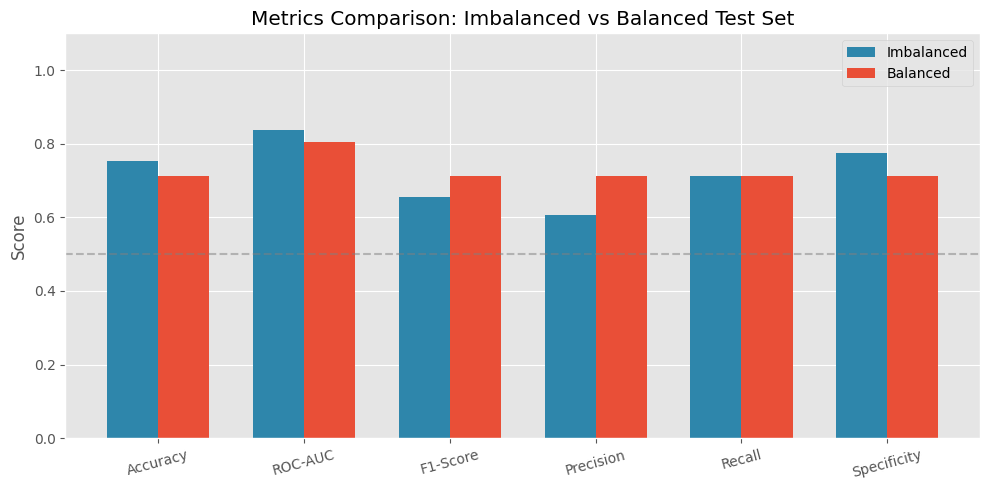

In [10]:
# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_imbalanced['metrics']))
width = 0.35

bars1 = ax.bar(x - width/2, results_imbalanced['metrics'].values(), width, label='Imbalanced', color='#2E86AB')
bars2 = ax.bar(x + width/2, results_balanced['metrics'].values(), width, label='Balanced', color='#E94F37')

ax.set_ylabel('Score')
ax.set_title('Metrics Comparison: Imbalanced vs Balanced Test Set')
ax.set_xticks(x)
ax.set_xticklabels(results_imbalanced['metrics'].keys(), rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("../plots/metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

## Part 6. Evaluation Plots

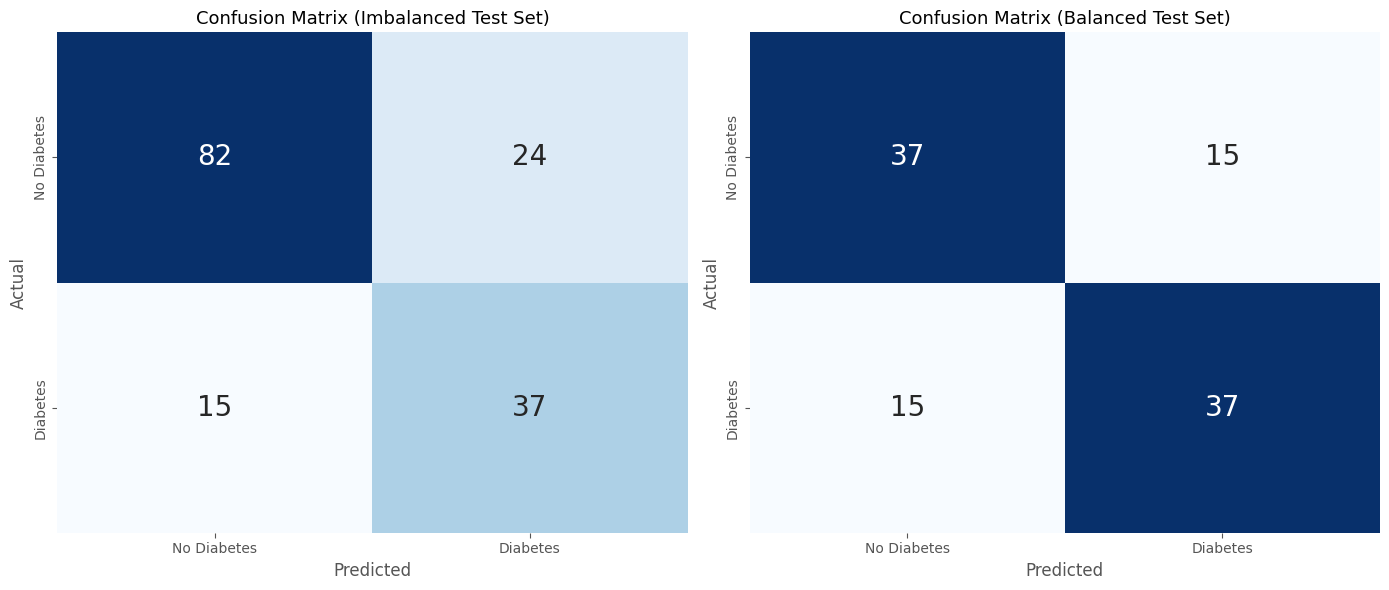

In [11]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, results, title in zip(axes, 
                               [results_imbalanced, results_balanced], 
                               ['Imbalanced Test Set', 'Balanced Test Set']):
    cm = confusion_matrix(results['y_true'], results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'],
                annot_kws={'size': 20}, cbar=False)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(f'Confusion Matrix ({title})', fontsize=13)

plt.tight_layout()
plt.savefig("../plots/confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

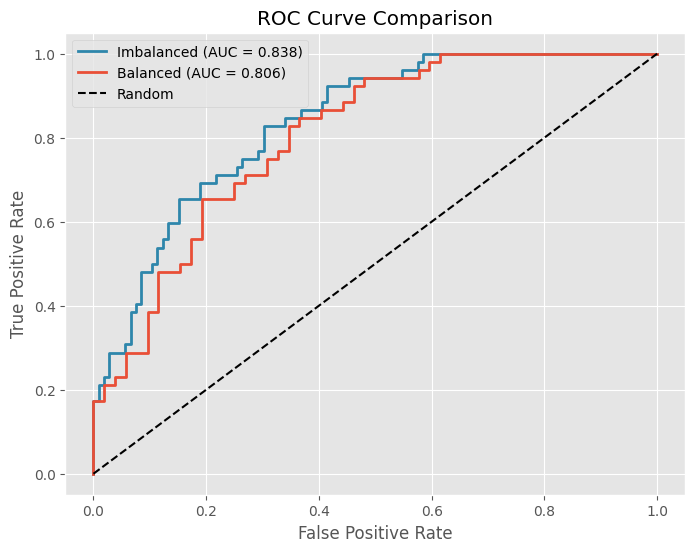

In [12]:
# ROC curves comparison
plt.figure(figsize=(8, 6))

for results, label, color in zip([results_imbalanced, results_balanced],
                                  ['Imbalanced', 'Balanced'],
                                  ['#2E86AB', '#E94F37']):
    fpr, tpr, _ = roc_curve(results['y_true'], results['y_proba'])
    auc = results['metrics']['ROC-AUC']
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {auc:.3f})", color=color)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig("../plots/roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

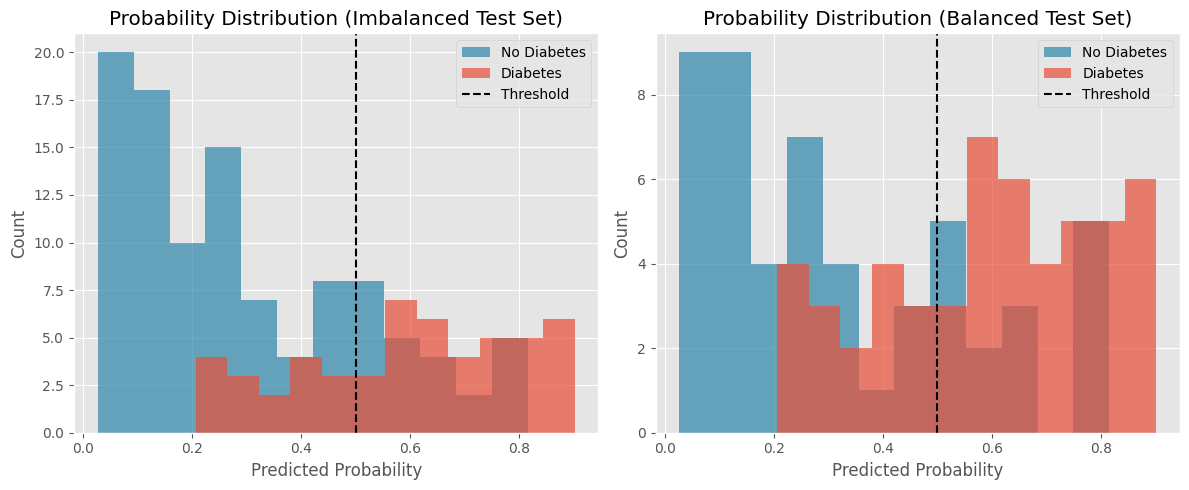

In [14]:
# Probability distributions comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, results, title in zip(axes,
                               [results_imbalanced, results_balanced],
                               ['Imbalanced Test Set', 'Balanced Test Set']):
    ax.hist(results['y_proba'][results['y_true'] == 0], bins=12, alpha=0.7, 
            label='No Diabetes', color='#2E86AB')
    ax.hist(results['y_proba'][results['y_true'] == 1], bins=12, alpha=0.7, 
            label='Diabetes', color='#E94F37')
    ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'Probability Distribution ({title})')
    ax.legend()

plt.tight_layout()
plt.savefig("../plots/probability_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

## Part 7. Summary

**Key Observations:**

1. **Accuracy** is higher on the imbalanced set due to the majority class bias. On the balanced set, accuracy reflects true classification ability.

2. **ROC-AUC** remains relatively stable across both settings, as it measures ranking ability independent of class distribution.

3. **Recall and Specificity** trade off differently depending on class balance - the balanced set provides clearer insight into per-class performance.

4. The **imbalanced evaluation** reflects real-world deployment performance, while the **balanced evaluation** shows the model's intrinsic ability to distinguish between classes.